In [1]:
from config.llm import llm

/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_key is not default parameter.
                openai_api_key was transferred to model_kwargs.
                Please confirm that openai_api_key is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_base is not default parameter.
                openai_api_base was transferred to model_kwargs.
                Please confirm that openai_api_base is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
from langchain_community.utilities.sql_database import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///../db/employees.db")

这一步是核心。每个工具就是一个 Python 函数，加上 @tool 装饰器就变成 LangChain 工具了。

有个关键点：docstring 一定要写好。因为 Agent 就是靠 docstring 来判断什么时候该调用哪个工具的。你不写清楚，Agent 就会一脸懵。

In [3]:
from langchain.tools import tool

In [4]:
# 逻辑很简单：传了表名就返回那张表的结构，没传就返回所有表的结构。如果表名不存在，告诉 Agent 有哪些表可以用。

@tool
def get_database_schema(table_name: str = None):
    """Get database schema information for SQL query generation.
    Use this first to understand the table structure before creating query."""
    if table_name:
        tables = db.get_usable_table_names()
        if table_name.lower() in [t.lower() for t in tables]:
            return db.get_table_info([table_name])
        else:
            return f"Error: Table '{table_name}' not found. Available tables: {', '.join(tables)}"
    else:
        return db.get_table_info()

In [20]:
# 生成 SQL 查询
@tool
def generate_sql_query(question: str, schema_info: str = None):
  """Generate SQL query from natural language questions.
  Use this after getting the database schema."""
  
  schema_to_use = schema_info if schema_info else db.get_table_info()
  
  prompt = f"""
   Based on the database schema: {schema_to_use}
  
   Generate SQL query to answer this question: {question}
   
   Rules:
- Use only SELECT statements (read-only, no write/update/delete)
- Include only existing columns and tables
- Add appropriate WHERE, GROUP BY, ORDER BY clauses as needed
- Limit results to 10 unless otherwise specified
- Use proper SQL syntax
- Return ONLY the SQL query, nothing else
  """
  
  response = llm.invoke(prompt)
  
  sql_query = response.content.strip()
  print(f"[Tool] Generated SQL query: {sql_query}...")
  return sql_query

In [7]:
import re

@tool
def validate_sql_query(query: str):
  """validate SQL query for safety checks and syntax before execution.
  Use this to check if a generated SQL query is safe to run"""
  
  clean_query = query.strip()
  clean_query = re.sub(r'```sql\s*', '', clean_query, flags=re.IGNORECASE)
  clean_query = re.sub(r'```\s*', '', clean_query)
  clean_query = clean_query.strip().rstrip(';')
  
  dangerous_keywords = ['INSERT', 'UPDATE', 'DELETE', 'DROP', 'ALTER', 'TRUNCATE', 'CREATE']
  for keyword in dangerous_keywords:
        if re.search(rf'\b{keyword}\b', clean_query, re.IGNORECASE):
            return f"Error: Only SELECT statements are allowed. Found '{keyword}' operation."

  # 检查是不是以 SELECT 开头
  if not clean_query.upper().startswith('SELECT'):
        return f"Error: Query must start with SELECT. Got: {clean_query[:30]}..."

  return clean_query

In [8]:
# 执行 SQL 查询
@tool
def execute_sql_query(query: str):
  """Execute a validated SQL query against the database
  Use this after generating and validating a SQL query.
  """
  
  validated = validate_sql_query.invoke({"query": query})
  if validated.startswith('Error'):
    return f"Query: {query}\nValidation failed with error: {validated}"
  
  result = db.run(validated)
  if result:
    return f"Query results:\n{result}"
  else:
    return "Query executed successfully but no results found."

In [10]:
@tool
def fix_sql_error(original_query: str, error_message: str, question: str):
    """Fix a failed SQL query based on the error message.
    Use this when a SQL query execution fails.
    """
    prompt = f"""The following SQL query failed:
Query: {original_query}
Error: {error_message}
Original question: {question}

Database schema:
{db.get_table_info()}

Please fix the specific error mentioned.
Still answer the original question.
Use only valid table and column names from the schema.
Follow proper SQL syntax.
Return ONLY the corrected SQL query, nothing else.
"""
    response = llm.invoke(prompt)
    fixed_query = response.content.strip()

    print(f"[Tool] Generated fixed SQL query: {fixed_query[:50]}...")
    return fixed_query

### 搭建agent

In [11]:
from typing import TypedDict, Annotated
from operator import add

class AgentState(TypedDict):
    messages: Annotated[list, add]

In [13]:
# 绑定工具到llm

tools = [get_database_schema, generate_sql_query, execute_sql_query, fix_sql_error]

llm_with_tools = llm.bind_tools(tools)

创建agent节点

In [14]:
from langchain_core.messages import SystemMessage

def agent_node(state: AgentState):
    system_prompt = """You are an expert SQL analyst working with an employee database.
Your workflow for answering questions:
1. Get the database schema to understand the structure
2. Generate a SQL query based on the question
3. Execute the SQL query to get results
4. If a query fails, use the fix tool and try again

Rules:
- Always follow the workflow step by step
- If a query fails, use the fix tool and try again
- Provide clear and informative answers
- Be precise with table and column names
- Handle errors gracefully and try to fix them
- If you fail after 3 attempts, explain what went wrong
"""
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

创建条件路由

In [15]:
# 这是整个图的"大脑"——看 Agent 最新的回复里有没有工具调用：
def should_continue(state: AgentState):
  last_message = state["messages"][-1]
  if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    print(f"[Router] Calling tools: {[tc['name'] for tc in last_message.tool_calls]}")
    return "tools"
  else:
    print("[Router] Agent is producing final answer")
    return "end"

组装langgraph

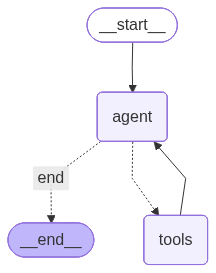

In [21]:
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode

def create_sql_agent():
    builder = StateGraph(AgentState)
    
    builder.add_node('agent', agent_node)
    builder.add_node('tools', ToolNode(tools))
    
    builder.add_edge(START, 'agent')
    builder.add_edge('tools', 'agent')
    
    builder.add_conditional_edges('agent', should_continue, {
      'tools': 'tools',
      'end': END
    })
    return builder.compile()

agent = create_sql_agent()

agent

In [22]:
from langchain_core.messages import HumanMessage

result = agent.invoke({
    "messages": [HumanMessage(content="公司一共有多少员工？")]
})

print(result["messages"][-1].content)

[Router] Calling tools: ['get_database_schema']
[Router] Calling tools: ['generate_sql_query']
[Tool] Generated SQL query: SELECT COUNT(*) FROM employees;...
[Router] Calling tools: ['execute_sql_query']
[Router] Agent is producing final answer
根据查询结果，公司一共有 **10名员工**。


In [23]:
result = agent.invoke({
    "messages": [HumanMessage(content="薪资最高的 5 个员工是谁？他们在哪个部门？需要多表查询的话就使用多表查询")]
})

print(result["messages"][-1].content)

[Router] Calling tools: ['get_database_schema']
[Router] Calling tools: ['generate_sql_query']
[Tool] Generated SQL query: ```sql
SELECT e.first_name, e.last_name, s.salary,...
[Router] Calling tools: ['execute_sql_query']
[Router] Calling tools: ['generate_sql_query']
[Tool] Generated SQL query: ```sql
SELECT
  e.first_name,
  e.last_name,
  s.s...
[Router] Calling tools: ['execute_sql_query']
[Router] Agent is producing final answer
根据查询结果，薪资最高的5个员工及其所在部门如下：

| 排名 | 姓名 | 薪资 | 部门 |
|------|------|------|------|
| 1 | Kyoichi Maliniak | $78,228 | Human Resources（人力资源） |
| 2 | Georgi Facello | $66,074 | Development（开发） |
| 3 | Bezalel Simmel | $65,909 | Sales（销售） |
| 4 | Sumant Peac | $60,689 | Quality Management（质量管理） |
| 5 | Tzvetan Zielinski | $56,724 | Research（研究） |

**查询说明：**
- 使用了多表查询，关联了 `employees`（员工）、`salaries`（薪资）、`dept_emp`（部门员工关系）和 `departments`（部门）四张表
- 为了确保准确性，对每个员工只取最新的薪资记录和最新的部门分配记录
- 结果按薪资降序排列，显示前5名
